In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
sys.path.append("../../../")
import data_loading as dl
from importlib import reload
reload(dl)

from microfit import run_plotter as rp
from microfit import histogram as hist

from microfit import variable_definitions as vdef
from microfit import selections

from microfit import detsys

In [2]:
keep_vars = [
    "Signal_1e1p", "mc_signal_1e1p", "nu_pdg", "TrueElecIdx", "TrueLeadProtonIdx", "InFV", "HasNoMesons",
    "TrueNElec", "TrueNProt", "TrueDeltaPT", "TrueDeltaAlphaT", "TruePN", "TrueAlpha3D",
    "nproton", "npion", "npi0", "nelec", "nmuon", "isVtxInFiducial", "ccnc",
    "Sel_1e1p", "sel_1e1p_w_cuts", "RecoElectronCandidateIdx", "RecoLeadProtonCandidateIdx", "InFV_reco",
    "RecoElecPassMomCut", "RecoLeadProtonPassMomCut", "n_reco_tracks", "n_reco_showers",
    "RecoDeltaPT", "RecoDeltaAlphaT", "RecoPN", "RecoAlpha3D", "RecoECal", "Reco_mag_q", "RecoPL",
    "nslice", "selected", "shr_energy_tot_cali", "_opfilter_pe_beam", "_opfilter_pe_veto", "bnbdata", "extdata",
    "CosmicIPAll3D", "hits_ratio", "shrmoliereavg", "subcluster", "trkfit", "tksh_distance",
    "shr_tkfit_nhits_tot", "shr_tkfit_dedx_max", "tksh_angle", "shr_trk_len"
]

In [3]:
RUN = ["3"]
#RUN = ["1","2","3_nocrt","3_crt","4b","4c","4d","5"]
#RUN = ["1","2","3","4b","4c","4d","5"] #important that it's a string 1) new format to include latest runs 2) to include 'mc_pdg' otherwise it gets dropped
blinded = True
data="bnb"

rundata, mc_weights, data_pot = dl.load_runs(
    RUN,
    data=data,
    loadpi0variables=False,
    loadshowervariables=True,
    loadrecoveryvars=False,
    loadsystematics=True,
    numupresel=False,
    loadnumuvariables=False,
    use_bdt=False,
    load_lee=False,
    load_nue_tki=True,
    keep_columns=keep_vars,
    blinded=blinded,
    load_crt_vars=False,
    enable_cache=True,
)

Loading run 3
Updating keep_columns with truth-filtering variables: {'ccnc', 'nu_pdg'}


In [4]:
run_combo = "Run"
for run in RUN:
    run_combo += run
print(run_combo)

Run3


### Calculating the integrated flux

In [5]:
# Zarko Pavlovic, Jun 22 2020
# /pnfs/uboone/persistent/uboonebeam/bnb_gsimple/bnb_gsimple_fluxes_01.09.2019_463_hist/readme.txt

Nominal_UB_XY_Surface = 256.35*233. # cm2
SoftFidSurface = 236. * 210.  # cm2
POTPerSpill = 4997.*5e8

# import uproot

# FluxFile = uproot.open('/pnfs/uboone/persistent/uboonebeam/bnb_gsimple/bnb_gsimple_fluxes_01.09.2019_463_hist/MCC9_FluxHist_volTPCActive.root')#['hEnue_cv']
# HistoFlux = FluxFile['hEnue_cv']
HistoFlux_int = 593641.00 # retrieved from the root file itself by running hEnue_cv->Integral()
#HistoFlux_int = 1.1007862e+08 # for hEnumu_cv

IntegratedFlux = (HistoFlux_int * data_pot / POTPerSpill / Nominal_UB_XY_Surface)
print(IntegratedFlux)

1021528083.966154


### Making the error plot

('RecoDeltaPT', None, None, '$\\delta p_T$ [GeV/c]', False, None, [0, 0.3, 1.7])

Loading devar histograms from file: /exp/uboone/data/users/mmoudgal/PELEE/detvar_cached_dataframes//run_3_RecoDeltaPT_bnb.json
Making plots for mc
Making plots for nue
smooth_detsys_variations: True

extra_query: None

include_detsys_variations: ['cv', 'lydown', 'lyatt', 'lyrayleigh', 'sce', 'recomb2', 'wiremodx', 'wiremodyz', 'wiremodthetaxz', 'wiremodthetayz']

[[20.65089499  4.47661012]
 [ 4.47661012  7.95045831]]

binning_def[0] bin counts: [37.738495   30.78312749]
total error: [0.18874789 0.19034039]

stat error: [0.06154302 0.0833423 ]

Ntargets error: [0.00921497 0.00903759]

POT error: [0.01842993 0.01807518]

smooth_detsys_variations: True

extra_query: None

include_detsys_variations: ['cv', 'lydown', 'lyatt', 'lyrayleigh', 'sce', 'recomb2', 'wiremodx', 'wiremodyz', 'wiremodthetaxz', 'wiremodthetayz']

[[20.65089499  4.47661012]
 [ 4.47661012  7.95045831]]

detsys error: [0.12041618 0.09159744]

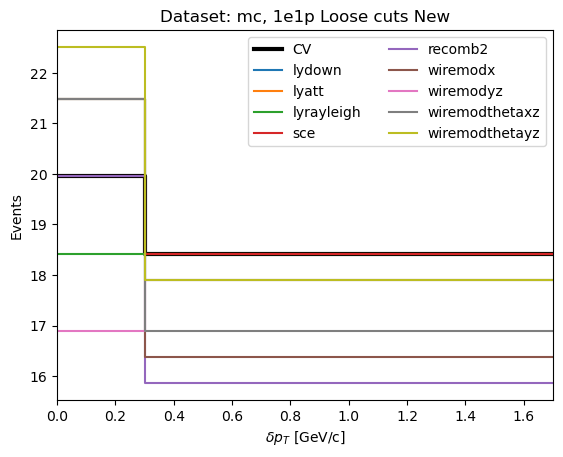

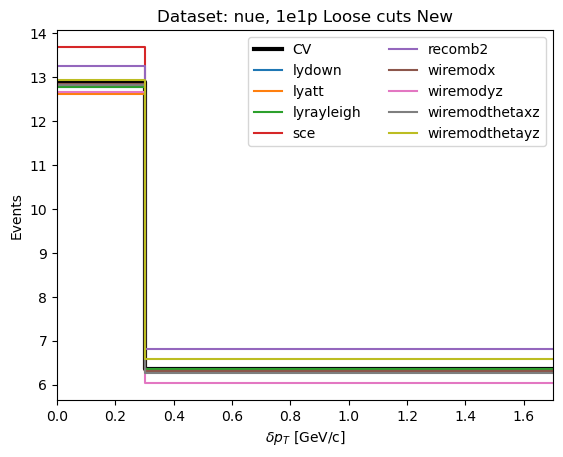

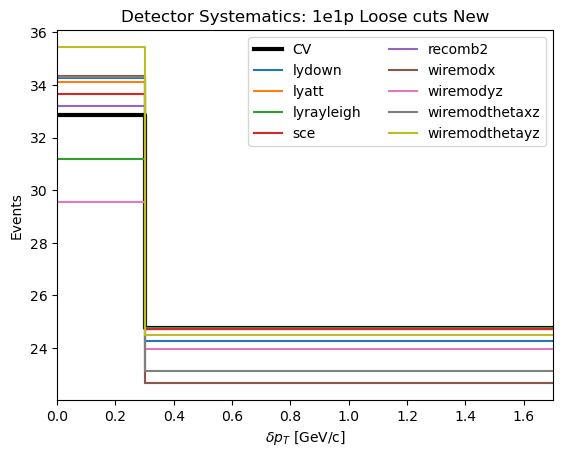

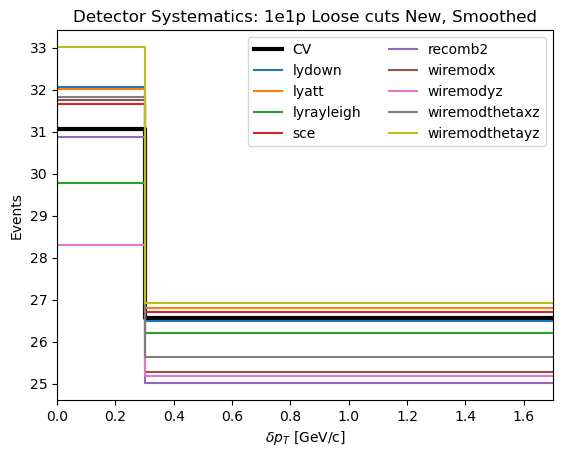

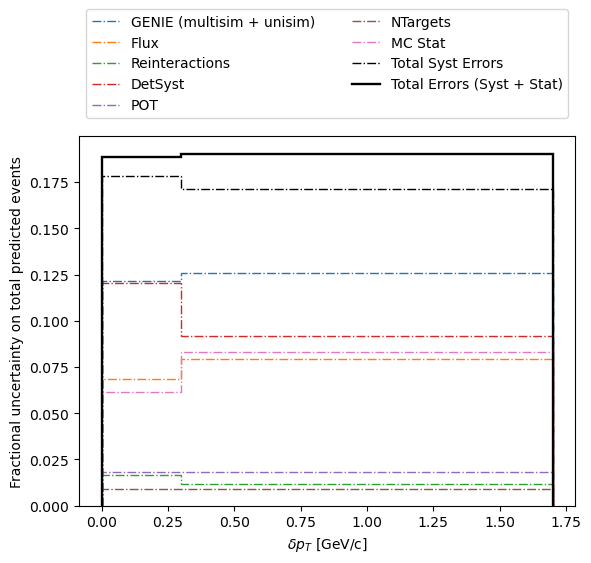

('RecoDeltaAlphaT', None, None, '$\\delta \\alpha_T$ [degrees]', False, None, [0, 80, 180])

Loading devar histograms from file: /exp/uboone/data/users/mmoudgal/PELEE/detvar_cached_dataframes//run_3_RecoDeltaAlphaT_bnb.json
Making plots for mc
Making plots for nue
smooth_detsys_variations: True

extra_query: None

include_detsys_variations: ['cv', 'lydown', 'lyatt', 'lyrayleigh', 'sce', 'recomb2', 'wiremodx', 'wiremodyz', 'wiremodthetaxz', 'wiremodthetayz']

[[ 6.899636    0.41046029]
 [ 0.41046029 32.47257617]]

binning_def[0] bin counts: [23.06136275 45.46356476]
total error: [0.18691863 0.19888164]

stat error: [0.08455398 0.06288581]

Ntargets error: [0.00845841 0.00947869]

POT error: [0.01691682 0.01895737]

smooth_detsys_variations: True

extra_query: None

include_detsys_variations: ['cv', 'lydown', 'lyatt', 'lyrayleigh', 'sce', 'recomb2', 'wiremodx', 'wiremodyz', 'wiremodthetaxz', 'wiremodthetayz']

[[ 6.899636    0.41046029]
 [ 0.41046029 32.47257617]]

detsys error: [0.11390

<Figure size 640x480 with 0 Axes>

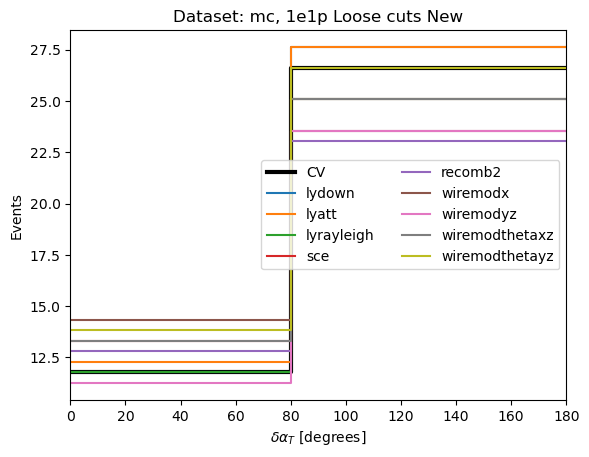

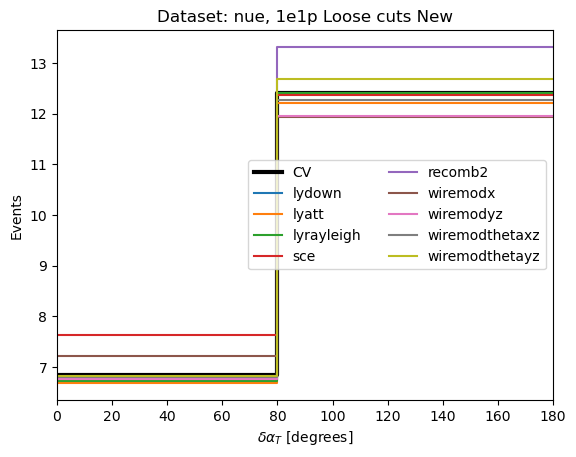

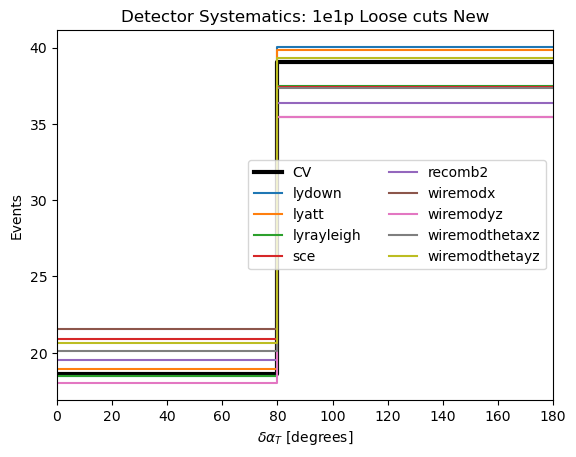

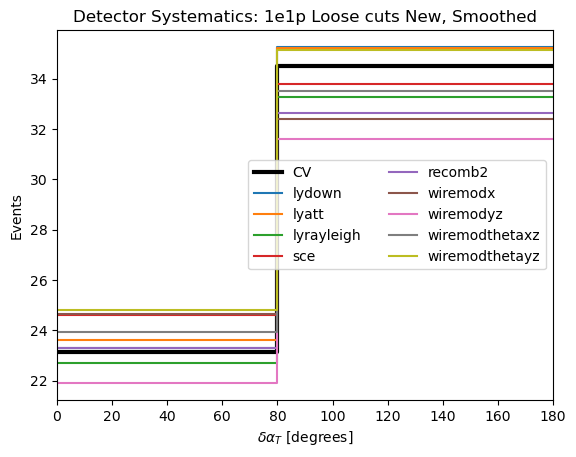

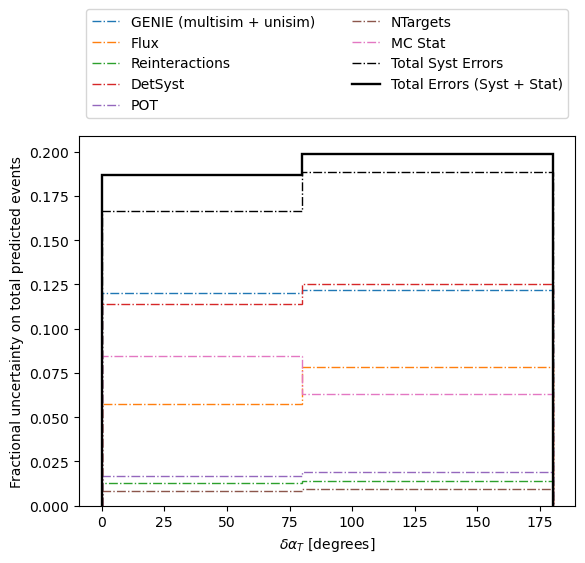

('RecoPN', None, None, '$p_n$ [GeV/c]', False, None, [0, 0.3, 1.7])

Loading devar histograms from file: /exp/uboone/data/users/mmoudgal/PELEE/detvar_cached_dataframes//run_3_RecoPN_bnb.json
Making plots for mc
Making plots for nue
smooth_detsys_variations: True

extra_query: None

include_detsys_variations: ['cv', 'lydown', 'lyatt', 'lyrayleigh', 'sce', 'recomb2', 'wiremodx', 'wiremodyz', 'wiremodthetaxz', 'wiremodthetayz']

[[ 5.46759361  4.42316549]
 [ 4.42316549 24.27078868]]

binning_def[0] bin counts: [25.65674155 42.56862089]
total error: [0.17328542 0.19766835]

stat error: [0.07067377 0.06889254]

Ntargets error: [0.00976906 0.00881687]

POT error: [0.01953812 0.01763374]

smooth_detsys_variations: True

extra_query: None

include_detsys_variations: ['cv', 'lydown', 'lyatt', 'lyrayleigh', 'sce', 'recomb2', 'wiremodx', 'wiremodyz', 'wiremodthetaxz', 'wiremodthetayz']

[[ 5.46759361  4.42316549]
 [ 4.42316549 24.27078868]]

detsys error: [0.0911374  0.11573171]

genie error: [0.

<Figure size 640x480 with 0 Axes>

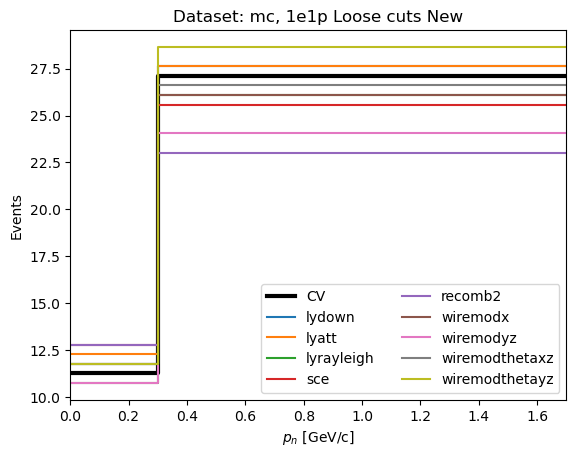

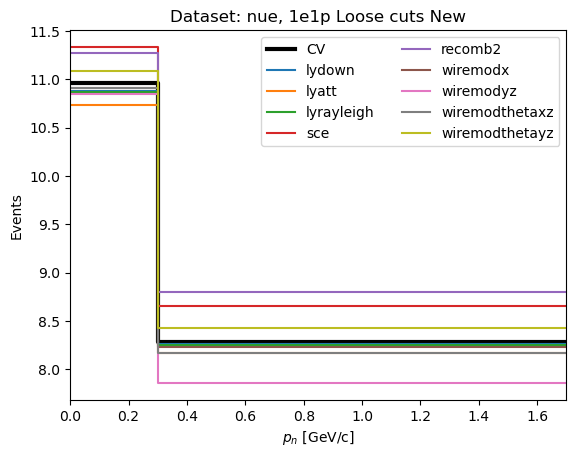

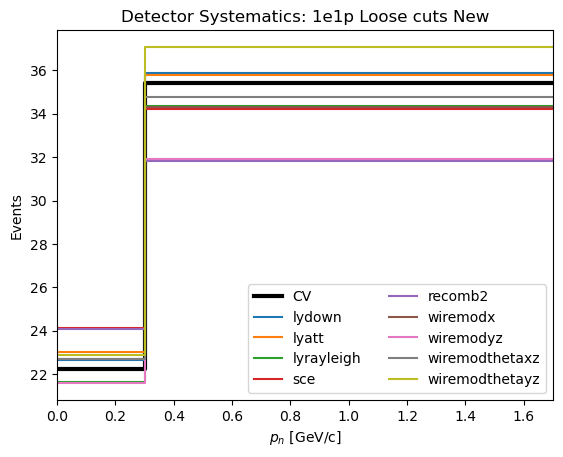

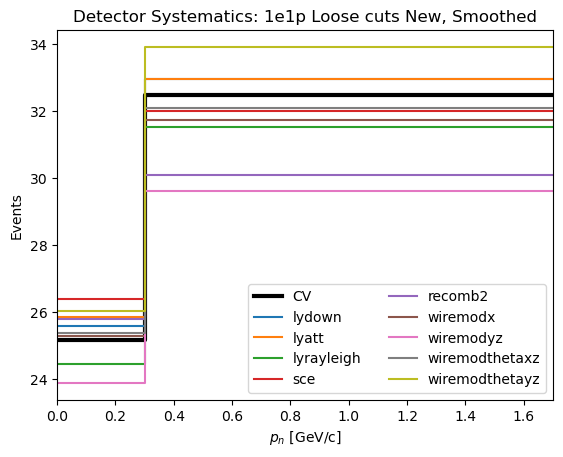

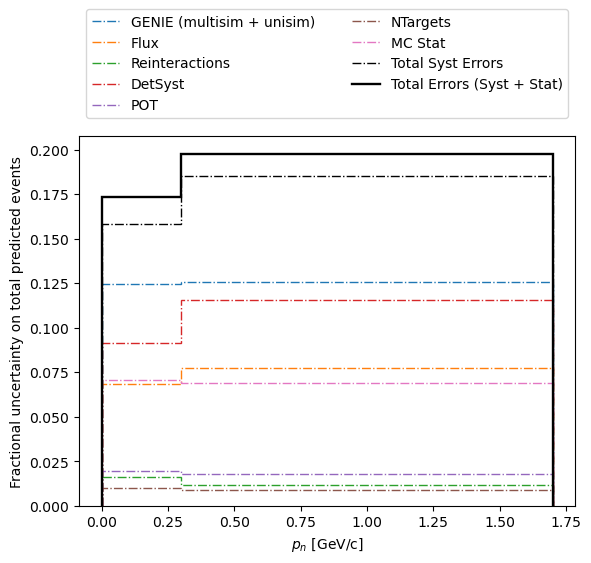

('RecoAlpha3D', None, None, '$\\alpha_{3D}$ [degrees]', False, None, [0, 90, 180])

Loading devar histograms from file: /exp/uboone/data/users/mmoudgal/PELEE/detvar_cached_dataframes//run_3_RecoAlpha3D_bnb.json
Making plots for mc
Making plots for nue
smooth_detsys_variations: True

extra_query: None

include_detsys_variations: ['cv', 'lydown', 'lyatt', 'lyrayleigh', 'sce', 'recomb2', 'wiremodx', 'wiremodyz', 'wiremodthetaxz', 'wiremodthetayz']

[[19.90894992  3.18999401]
 [ 3.18999401  7.87532626]]

binning_def[0] bin counts: [30.22195811 38.3029694 ]
total error: [0.21716652 0.16387698]

stat error: [0.07150363 0.07056962]

Ntargets error: [0.00990197 0.00853042]

POT error: [0.01980394 0.01706083]

smooth_detsys_variations: True

extra_query: None

include_detsys_variations: ['cv', 'lydown', 'lyatt', 'lyrayleigh', 'sce', 'recomb2', 'wiremodx', 'wiremodyz', 'wiremodthetaxz', 'wiremodthetayz']

[[19.90894992  3.18999401]
 [ 3.18999401  7.87532626]]

detsys error: [0.14763916 0.0732658

<Figure size 640x480 with 0 Axes>

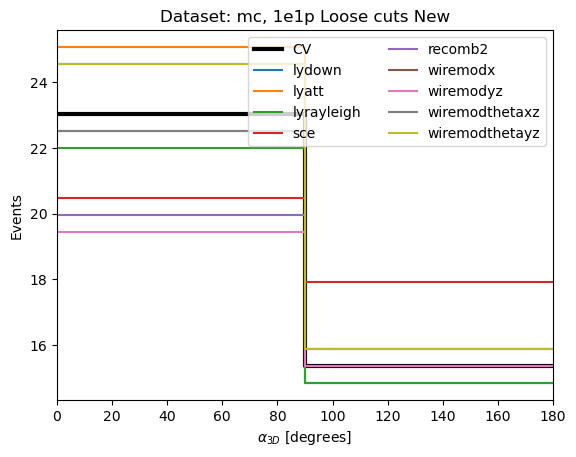

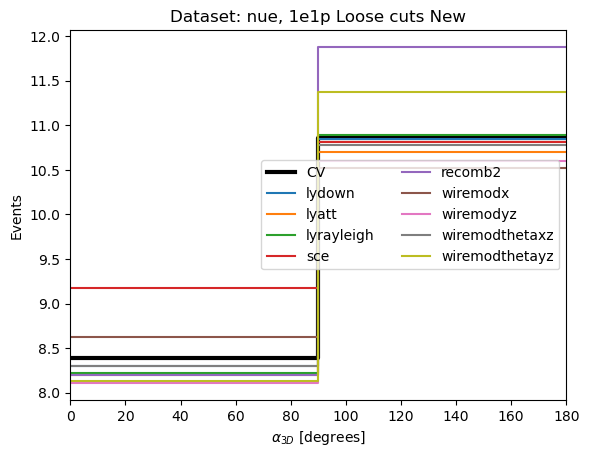

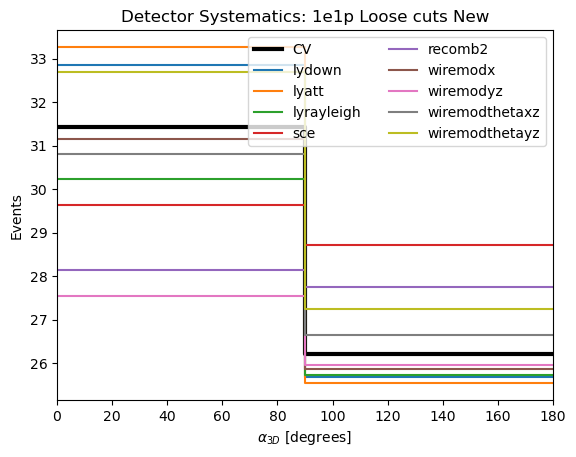

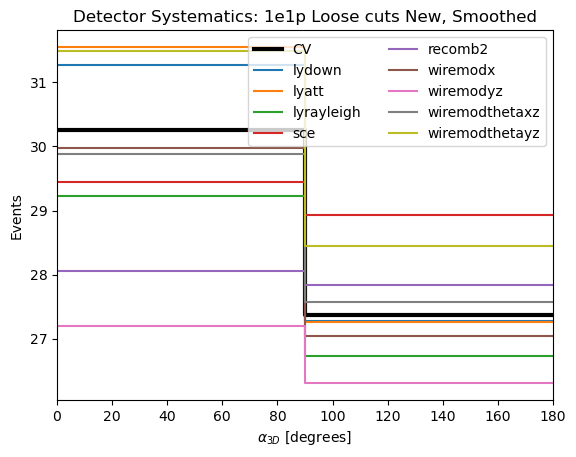

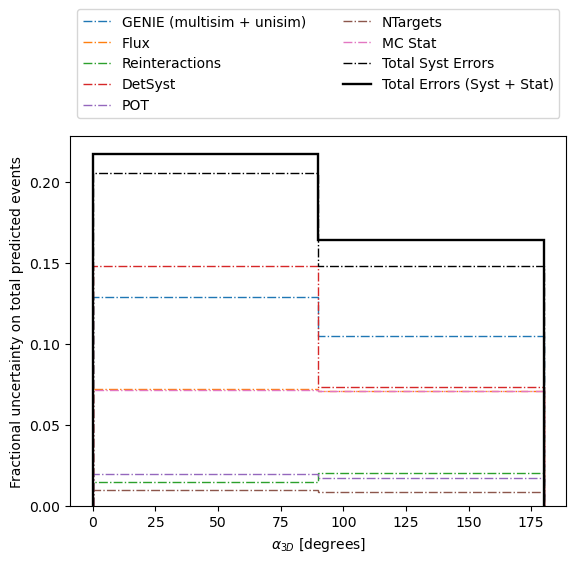

<Figure size 640x480 with 0 Axes>

In [6]:
selection = "OnePL_new"
preselection = "OneP_new"

#detector_variations = ["cv","lydown","lyatt","lyrayleigh","sce","recomb2","wiremodx","wiremodyz","wiremodthetaxz","wiremodthetayz"]

IntegratedFlux = 1

for binning_def in vdef.TKI_variables_1e1p:
    # some binning definitions have more than 4 elements,
    # we ignore the last ones for now
    #binning = hist.Binning.from_config(*binning_def[:4])
    binning = hist.Binning.from_config(*binning_def)  # for variable bin sizes
    print(binning_def)
    print()
    
    # Load detvars
    detvar_data = detsys.make_variations(
    run_numbers=RUN,
    data="bnb",
    binning=binning.copy(),
    selection=selection,
    preselection=preselection,
    use_kde_smoothing=False,
    make_plots=True,
    plot_output_dir= "/exp/uboone/app/users/mmoudgal/PELEE/sandbox/mmoudgalya/analysis_1e1p/analysis_plots/detsys/",
    enable_detvar_cache=True,
    detvar_cache_dir="/exp/uboone/data/users/mmoudgal/PELEE/detvar_cached_dataframes/",
    extra_selection_query=None,
    show_plots=True,
    #variations=detector_variations,
    #**dl_kwargs,
    loadpi0variables=False,
    loadshowervariables=True,
    loadrecoveryvars=False,
    loadsystematics=True,
    numupresel=False,
    loadnumuvariables=False,
    use_bdt=False,
    load_lee=False,
    load_nue_tki=True,
    keep_columns=keep_vars,
    blinded=blinded,
    load_crt_vars=False,
    enable_cache=True,
    )
    
    
    # Total error
    signal_generator = hist.RunHistGenerator(
        rundata,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        sideband_generator=None,
        uncertainty_defaults=None,
        detvar_data=detvar_data,
        normalization_uncertainty=[0.01,0.02]
    )
    total_prediction = signal_generator.get_total_prediction(include_multisim_errors=True, add_precomputed_detsys=True)
    bin_counts = total_prediction.bin_counts
    bin_edges = binning.bin_edges
    n_bins = len(bin_edges) - 1
    print(f"binning_def[0] bin counts:", bin_counts)
    flux_norm_total_prediction = total_prediction / IntegratedFlux
    total_cov = flux_norm_total_prediction.covariance_matrix
    total_error = np.sqrt(np.diagonal(total_cov)) / bin_counts
    print('total error:', total_error)
    print()
    
    # Stat error 
    #(included by default - just need to turn flags off for syst errors)
    # Hence, will need to subtract stat_cov when calculating all the individual syst error contributions
    signal_generator_stat = hist.RunHistGenerator(
        rundata,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        sideband_generator=None,
        uncertainty_defaults=None,
        detvar_data=detvar_data,
        normalization_uncertainty=None
    )
    
    total_prediction_stat = signal_generator_stat.get_total_prediction(include_multisim_errors=False, add_precomputed_detsys=False)
    flux_norm_total_prediction_stat = total_prediction_stat / IntegratedFlux
    stat_cov = flux_norm_total_prediction_stat.covariance_matrix
    stat_error = np.sqrt(np.diagonal(stat_cov)) / bin_counts
    print('stat error:', stat_error)
    print()
    
    # Ntargets error
    signal_generator_Ntargets = hist.RunHistGenerator(
        rundata,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        sideband_generator=None,
        uncertainty_defaults=None,
        detvar_data=None,
        normalization_uncertainty=[0.01]
    )
    
    total_prediction_Ntargets = signal_generator_Ntargets.get_total_prediction(include_multisim_errors=False, add_precomputed_detsys=False)
    flux_norm_total_prediction_Ntargets = total_prediction_Ntargets / IntegratedFlux
    Ntargets_cov = flux_norm_total_prediction_Ntargets.covariance_matrix - stat_cov
    Ntargets_error = np.sqrt(np.diagonal(Ntargets_cov)) / bin_counts
    print('Ntargets error:', Ntargets_error)
    print()
    
    # POT error
    signal_generator_POT = hist.RunHistGenerator(
        rundata,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        sideband_generator=None,
        uncertainty_defaults=None,
        detvar_data=None,
        normalization_uncertainty=[0.02]
    )
    
    total_prediction_POT = signal_generator_POT.get_total_prediction(include_multisim_errors=False, add_precomputed_detsys=False)
    flux_norm_total_prediction_POT = total_prediction_POT / IntegratedFlux
    POT_cov = flux_norm_total_prediction_POT.covariance_matrix - stat_cov
    POT_error = np.sqrt(np.diagonal(POT_cov)) / bin_counts
    print('POT error:', POT_error)
    print()
    
    # detsys error
    signal_generator_detsys = hist.RunHistGenerator(
        rundata,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        sideband_generator=None,
        uncertainty_defaults=None,
        detvar_data=detvar_data,
        normalization_uncertainty=None
    )
    
    total_prediction_detsys = signal_generator_detsys.get_total_prediction(include_multisim_errors=False, add_precomputed_detsys=True)
    flux_norm_total_prediction_detsys = total_prediction_detsys / IntegratedFlux
    detsys_cov = flux_norm_total_prediction_detsys.covariance_matrix - stat_cov
    detsys_error = np.sqrt(np.diagonal(detsys_cov)) / bin_counts
    print('detsys error:', detsys_error)
    print()
    
    # Multisim errors:
    signal_generator_multisim = hist.RunHistGenerator(
        rundata,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        sideband_generator=None,
        uncertainty_defaults=None,
        detvar_data=None,
        normalization_uncertainty=None
    )
    
    mc_hist_generator = signal_generator_multisim.mc_hist_generator
    
    # GENIE error
    genie_cov = (mc_hist_generator.calculate_multisim_uncertainties(multisim_weight_column="weightsGenie")) / IntegratedFlux**2
    genie_error = np.sqrt(np.diagonal(genie_cov)) / bin_counts
    print('genie error:', genie_error)
    print()
    
    # GENIE Unisim
    genie_unisim_cov = (mc_hist_generator.calculate_unisim_uncertainties()) / IntegratedFlux**2
    genie_unisim_error = np.sqrt(np.diagonal(genie_unisim_cov)) / bin_counts
    print('genie unisim error:', genie_unisim_error)
    print()
    
    # Flux error
    flux_cov = (mc_hist_generator.calculate_multisim_uncertainties(multisim_weight_column="weightsFlux")) / IntegratedFlux**2
    flux_error = np.sqrt(np.diagonal(flux_cov)) / bin_counts
    print('flux error:', flux_error)
    print()
    
    # Reinteraction error
    reint_cov = (mc_hist_generator.calculate_multisim_uncertainties(multisim_weight_column="weightsReint")) / IntegratedFlux**2
    reint_error = (np.sqrt(np.diagonal(reint_cov)) / bin_counts)
    print('reint error:', reint_error)
    print()
    
    # All errors except stats (total systematics error)
    only_syst_error = np.sqrt(np.diagonal(Ntargets_cov + POT_cov + detsys_cov + genie_cov + flux_cov + reint_cov + genie_unisim_cov)) / bin_counts
    all_except_stat_error = np.sqrt(np.diagonal(total_cov - stat_cov)) / bin_counts
    print("Only syst error:", only_syst_error)
    print()
    print("All except stat error:", all_except_stat_error)
    print()
    
    diff = only_syst_error - all_except_stat_error
    print('diff:', diff)
    print()

    
    # Plotting the fractional errors
    
    fig, ax2 = plt.subplots()
        
    #ax2.stairs(genie_error, bin_edges, label='GENIE', linestyle='dashdot')
    ax2.stairs(genie_error+genie_unisim_error, bin_edges, label='GENIE (multisim + unisim)', linestyle='dashdot')
    ax2.stairs(flux_error, bin_edges, label='Flux', linestyle='dashdot')
    ax2.stairs(reint_error, bin_edges, label='Reinteractions', linestyle='dashdot')
    ax2.stairs(detsys_error, bin_edges, label='DetSyst', linestyle='dashdot')
    ax2.stairs(POT_error, bin_edges, label='POT', linestyle='dashdot')
    ax2.stairs(Ntargets_error, bin_edges, label='NTargets', linestyle='dashdot')
    ax2.stairs(stat_error, bin_edges, label='MC Stat', linestyle='dashdot')
        
    ax2.stairs(only_syst_error, bin_edges, label='Total Syst Errors', linestyle='dashdot', color='black')
    ax2.stairs(total_error, bin_edges, label='Total Errors (Syst + Stat)', linestyle='solid', color='black', lw=1.7)
    
    ax2.set_xlabel(binning.variable_tex)
    ax2.set_ylabel('Fractional uncertainty on total predicted events')
    ax2.legend(bbox_to_anchor=(0, 1.03, 1, 0.3), loc="lower left", mode="expand", ncol=2)
    plt.savefig(f'analysis_plots/errors/total_errors_{data}_{run_combo}_{binning_def[0]}_{binning_def[1]}bins.pdf', bbox_inches='tight')
    plt.savefig(f'analysis_plots/errors/total_errors_{data}_{run_combo}_{binning_def[0]}_{binning_def[1]}bins.png', bbox_inches='tight')
    plt.show()
    plt.clf()
    


## Troubleshooting

('RecoDeltaPT', None, None, '$\\delta p_T$ [GeV/c]', False, None, [0, 0.3, 1.7])

binning from config: 
 Binning(variable='RecoDeltaPT', bin_edges=array([0. , 0.3, 1.7]), label='RecoDeltaPT', variable_tex='$\\delta p_T$ [GeV/c]', variable_tex_short=None, is_log=False, selection_query=None, selection_key=None, preselection_key=None, selection_tex=None, selection_tex_short=None)

binning from config copy: 
 Binning(variable='RecoDeltaPT', bin_edges=array([0. , 0.3, 1.7]), label='RecoDeltaPT', variable_tex='$\\delta p_T$ [GeV/c]', variable_tex_short=None, is_log=False, selection_query=None, selection_key=None, preselection_key=None, selection_tex=None, selection_tex_short=None)

Loading devar histograms from file: /exp/uboone/data/users/mmoudgal/PELEE/detvar_cached_dataframes//run_3_RecoDeltaPT_bnb.json
Making plots for mc
Making plots for nue

detvar binning: 
 Binning(variable='RecoDeltaPT', bin_edges=array([0. , 0.3, 1.7]), label='RecoDeltaPT', variable_tex='$\\delta p_T$ [GeV/c]', var

../../../data_loading.py:854: RuntimeWarning: invalid value encountered in true_divide
  df["proton_pz"] = np.where((mc_E_prot > 0), mc_pz_prot / mc_p_prot, np.nan)


Calc true TKI variables for leading proton only
Calc true GKI variables for leading proton only
Calc reco TKI variables for leading proton only
Calc reco GKI variables for leading proton only
/exp/uboone/data/users/cthorpe/PELEE_2023_Samples/run3/detvar/nuepresel/prodgenie_bnb_intrinsic_nue_overlay_DetVar_CV_reco2_v08_00_00_38_run3b_reco2_reco2.root
Calc true TKI variables for leading proton only
Calc true GKI variables for leading proton only
Calc reco TKI variables for leading proton only
Calc reco GKI variables for leading proton only
/exp/uboone/data/users/cthorpe/PELEE_2023_Samples/run3/detvar/nuepresel/overlay_pelee_ntuples_bnb_nu_detvar_run3_LYDown_reprocess_ana.root
Calc true TKI variables for leading proton only
Calc true GKI variables for leading proton only
Calc reco TKI variables for leading proton only
Calc reco GKI variables for leading proton only
/exp/uboone/data/users/cthorpe/PELEE_2023_Samples/run3/detvar/nuepresel/prodgenie_bnb_intrinsic_nue_overlay_DetVar_LYDown_v08

../../../data_loading.py:854: RuntimeWarning: invalid value encountered in true_divide
  df["proton_pz"] = np.where((mc_E_prot > 0), mc_pz_prot / mc_p_prot, np.nan)


Calc true TKI variables for leading proton only
Calc true GKI variables for leading proton only
Calc reco TKI variables for leading proton only
Calc reco GKI variables for leading proton only
/exp/uboone/data/users/cthorpe/PELEE_2023_Samples/run3/detvar/nuepresel/prodgenie_bnb_intrinsic_nue_overlay_DetVar_CV_reco2_v08_00_00_38_run3b_reco2_reco2.root
Calc true TKI variables for leading proton only
Calc true GKI variables for leading proton only
Calc reco TKI variables for leading proton only
Calc reco GKI variables for leading proton only
/exp/uboone/data/users/cthorpe/PELEE_2023_Samples/run3/detvar/nuepresel/overlay_pelee_ntuples_bnb_nu_detvar_run3_LYDown_reprocess_ana.root
Calc true TKI variables for leading proton only
Calc true GKI variables for leading proton only
Calc reco TKI variables for leading proton only
Calc reco GKI variables for leading proton only
/exp/uboone/data/users/cthorpe/PELEE_2023_Samples/run3/detvar/nuepresel/prodgenie_bnb_intrinsic_nue_overlay_DetVar_LYDown_v08

../../../data_loading.py:854: RuntimeWarning: invalid value encountered in true_divide
  df["proton_pz"] = np.where((mc_E_prot > 0), mc_pz_prot / mc_p_prot, np.nan)


Calc true TKI variables for leading proton only
Calc true GKI variables for leading proton only
Calc reco TKI variables for leading proton only
Calc reco GKI variables for leading proton only
/exp/uboone/data/users/cthorpe/PELEE_2023_Samples/run3/detvar/nuepresel/prodgenie_bnb_intrinsic_nue_overlay_DetVar_CV_reco2_v08_00_00_38_run3b_reco2_reco2.root
Calc true TKI variables for leading proton only
Calc true GKI variables for leading proton only
Calc reco TKI variables for leading proton only
Calc reco GKI variables for leading proton only
/exp/uboone/data/users/cthorpe/PELEE_2023_Samples/run3/detvar/nuepresel/overlay_pelee_ntuples_bnb_nu_detvar_run3_LYDown_reprocess_ana.root
Calc true TKI variables for leading proton only
Calc true GKI variables for leading proton only
Calc reco TKI variables for leading proton only
Calc reco GKI variables for leading proton only
/exp/uboone/data/users/cthorpe/PELEE_2023_Samples/run3/detvar/nuepresel/prodgenie_bnb_intrinsic_nue_overlay_DetVar_LYDown_v08

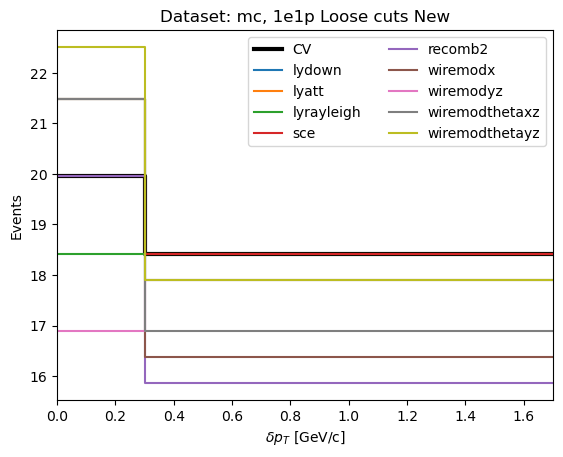

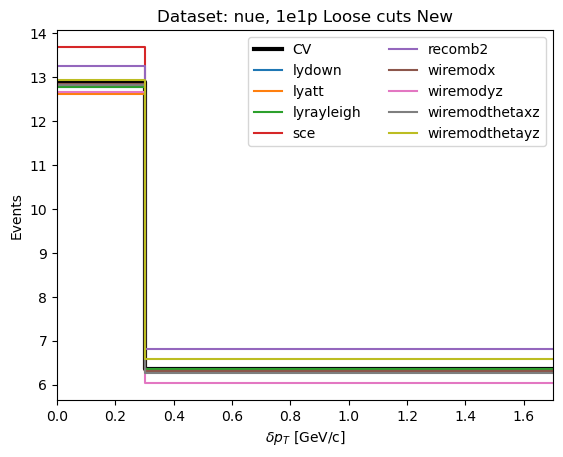

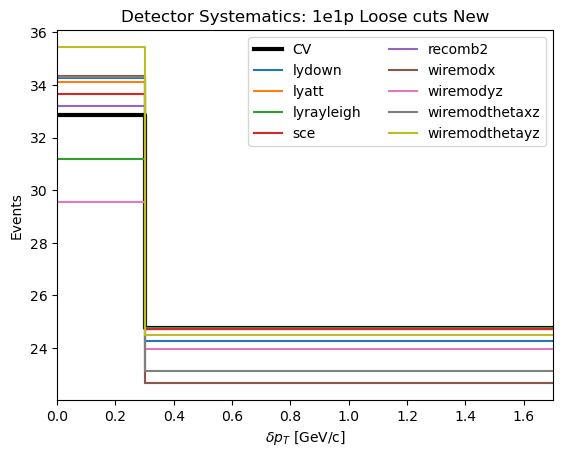

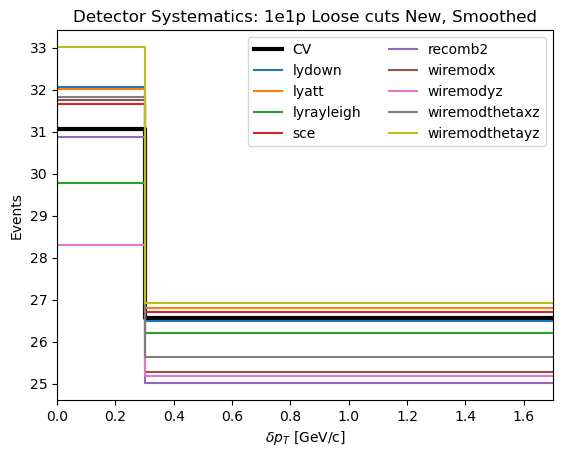

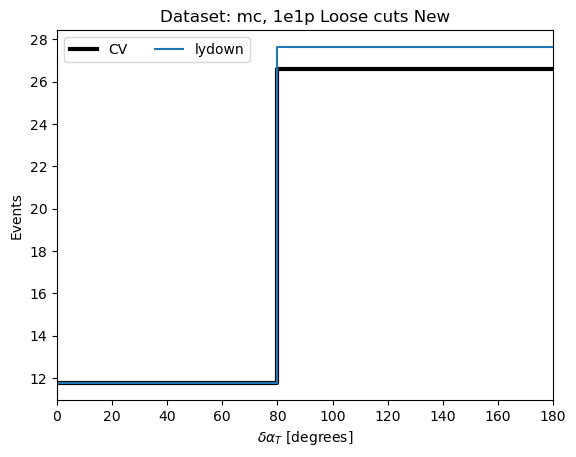

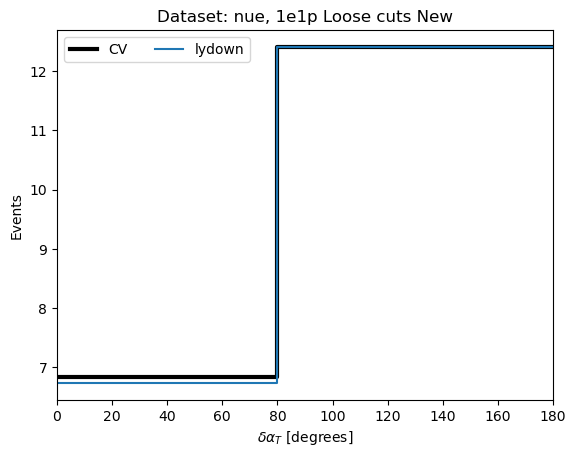

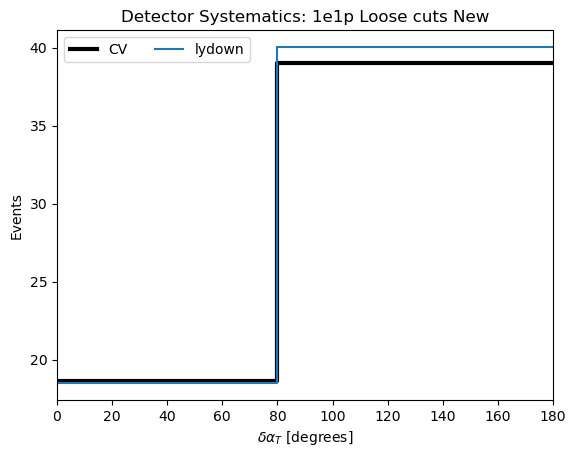

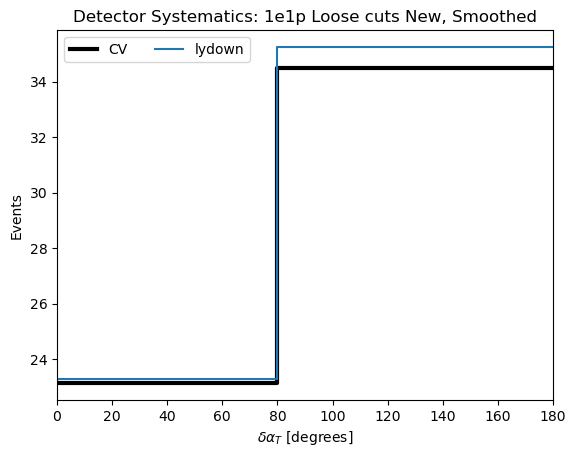

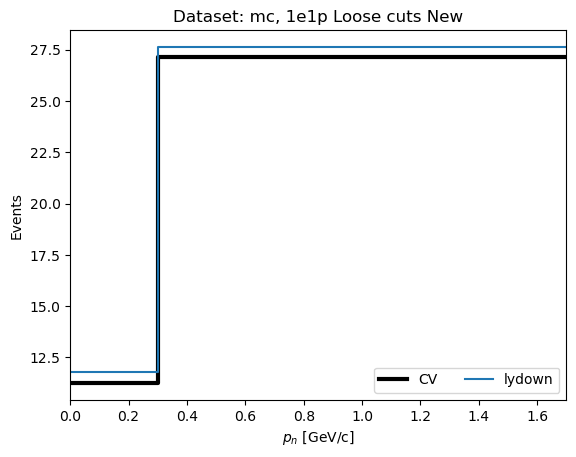

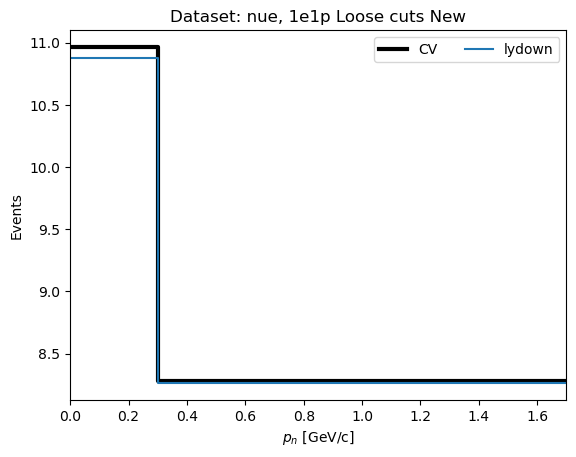

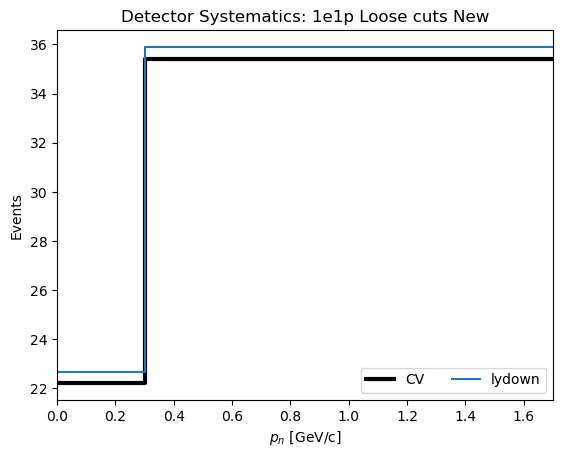

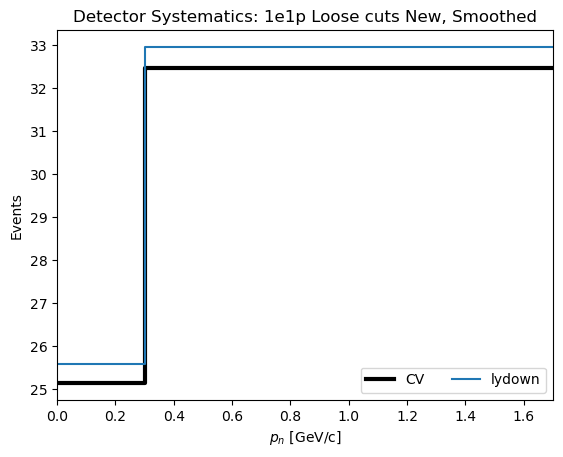

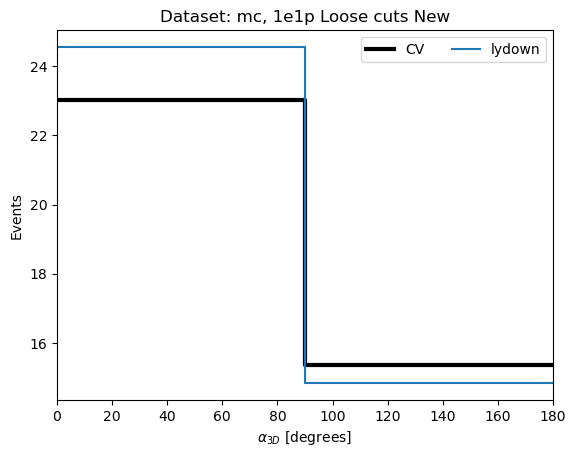

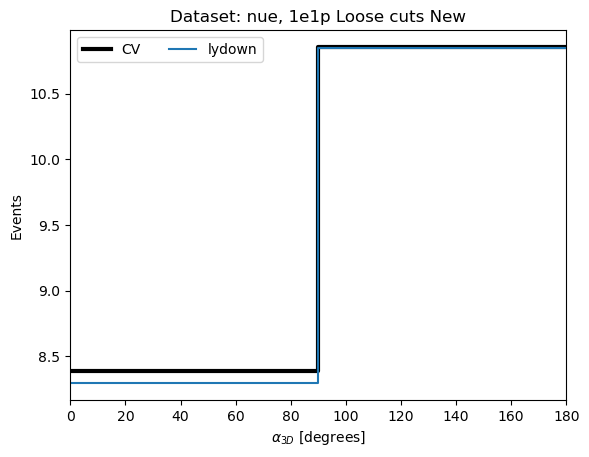

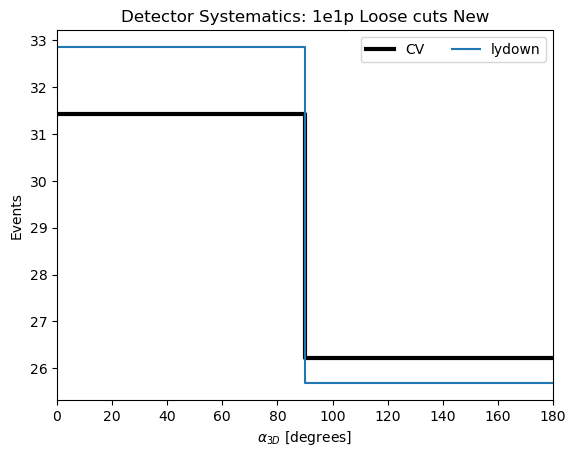

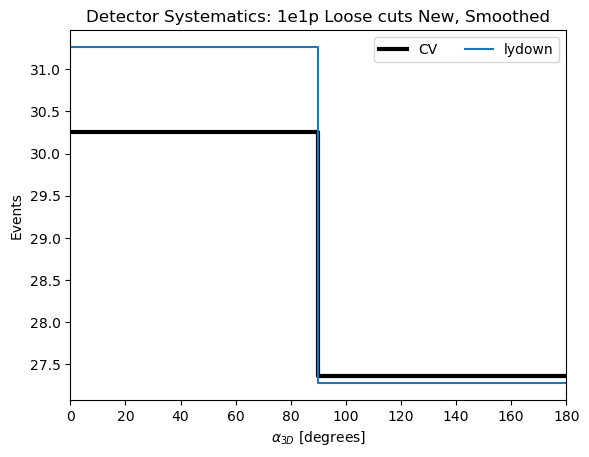

In [7]:
selection = "OnePL_new"
preselection = "OneP_new"

detector_variations = ["cv","lydown"]

for binning_def in vdef.TKI_variables_1e1p:
    binning = hist.Binning.from_config(*binning_def)  # for variable bin sizes
    print(binning_def)
    print()
    print('binning from config: \n', binning)
    print()
    print('binning from config copy: \n', binning.copy())
    print()
    
    detvar_data = detsys.make_variations(
    run_numbers=RUN,
    data="bnb",
    binning=binning,
    selection=selection,
    preselection=preselection,
    use_kde_smoothing=False,
    make_plots=True,
    plot_output_dir= "/exp/uboone/app/users/mmoudgal/PELEE/sandbox/mmoudgalya/analysis_1e1p/analysis_plots/detsys/",
    enable_detvar_cache=True,
    detvar_cache_dir="/exp/uboone/data/users/mmoudgal/PELEE/detvar_cached_dataframes/",
    extra_selection_query=None,
    show_plots=True,
    variations=detector_variations,
    #**dl_kwargs,
    loadpi0variables=False,
    loadshowervariables=True,
    loadrecoveryvars=False,
    loadsystematics=True,
    numupresel=False,
    loadnumuvariables=False,
    use_bdt=False,
    load_lee=False,
    load_nue_tki=True,
    keep_columns=keep_vars,
    blinded=blinded,
    load_crt_vars=False,
    enable_cache=False,
    )
    
    print()
    print('detvar binning: \n', detvar_data["binning"])
    print()